## 1. Planteamiento del problema

Interconnect enfrenta un problema de **clasificación binaria supervisada**: a partir de los atributos conocidos de cada cliente (contrato, demografía, servicios contratados y consumo), se busca estimar la probabilidad de que cancele su contrato en el corto plazo.

El valor de negocio no reside únicamente en clasificar con precisión, sino en **ordenar correctamente** a los clientes por nivel de riesgo. Por esta razón, la métrica principal del modelo es **AUC-ROC** y no la exactitud: las clases están desbalanceadas y el uso operativo del modelo consistirá en priorizar una lista de clientes a contactar para ofrecerles promociones o extender su contrato.

### Estrategia de análisis

1. **Carga, auditoría de calidad y unificación.** Se cargan los cuatro archivos CSV, se auditan tipos de dato, valores faltantes y duplicados, y se unen por `customerID` mediante un *left join* desde `contract.csv`, la tabla con cobertura completa. Esta decisión preserva a todos los clientes y permite codificar la ausencia de servicio en `internet` y `phone` como "no contratado".
2. **Construcción de variables de negocio.** Se generan las variables clave: `Churn` (booleano), `DaysActive` (antigüedad en días) y `LTV` (valor económico estimado por cliente).
3. **Análisis de Churn por segmento.** Se evalúan las cancelaciones por tipo de contrato y por año de inicio para identificar los segmentos de mayor riesgo.
4. **Cuantificación del impacto.** Se estima la pérdida monetaria asociada al Churn y se desglosa por tipo de contrato.
5. **Validación estadística** de las diferencias observadas entre el grupo de clientes activos y el grupo de cancelados.

## 2. Datos

### Fuentes

La información proviene de cuatro archivos CSV con orígenes distintos:

- `contract.csv` — información del contrato.
- `personal.csv` — datos personales del cliente.
- `internet.csv` — servicios de internet contratados.
- `phone.csv` — servicios telefónicos contratados.

En todos los archivos, la columna `customerID` contiene un código único asignado a cada cliente y funciona como llave de unión. La información del contrato es válida a partir del 1 de febrero de 2020.

In [1443]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

from pathlib import Path 

RANDOM_SEED = 56789

In [1444]:
FOLDER   = Path.cwd().parent
DATABASE = FOLDER / 'Data'

contract_path = DATABASE / 'contract.csv'
internet_path = DATABASE / 'internet.csv'
personal_path = DATABASE / 'personal.csv'
phone_path    = DATABASE / 'phone.csv'

contract = pd.read_csv(contract_path)
internet = pd.read_csv(internet_path)
personal = pd.read_csv(personal_path)
phone    = pd.read_csv(phone_path)

print(contract.shape, internet.shape, personal.shape, phone.shape)


(7043, 8) (5517, 8) (7043, 5) (6361, 2)


### Estandarización de columnas

Para facilitar el manejo posterior, se homogeneiza la nomenclatura de las columnas a **PascalCase**: la primera letra de cada nombre pasa a mayúscula y se conservan las mayúsculas internas. Así, `customerID` se convierte en `CustomerID` y `MonthlyCharges` permanece sin cambios.

In [1445]:
datasets = [contract, internet, phone, personal]

In [1446]:
# Normaliza los nombres de columnas a PascalCase.
# Modifica cada DataFrame in-place. Preserva las mayúsculas internas,
# así customerID -> CustomerID y MonthlyCharges queda igual.

def PascalCase(datasets):
    for dataset in datasets:
        dataset.columns = dataset.columns.str[0].str.upper() + dataset.columns.str[1:]

In [1447]:
# Aplica la estandarizacion y verifica los tipos resultantes
PascalCase(datasets)

for nombre, df in zip(['contract', 'internet', 'phone', 'personal'], datasets):
    print(f'-- {nombre} --\n')
    for col, dtype in df.dtypes.items():
        print(f'  {col:<20} {dtype}')
    print('\n')

-- contract --

  CustomerID           object
  BeginDate            object
  EndDate              object
  Type                 object
  PaperlessBilling     object
  PaymentMethod        object
  MonthlyCharges       float64
  TotalCharges         object


-- internet --

  CustomerID           object
  InternetService      object
  OnlineSecurity       object
  OnlineBackup         object
  DeviceProtection     object
  TechSupport          object
  StreamingTV          object
  StreamingMovies      object


-- phone --

  CustomerID           object
  MultipleLines        object


-- personal --

  CustomerID           object
  Gender               object
  SeniorCitizen        int64
  Partner              object
  Dependents           object




In [1448]:
# Convierte df[col] de string a entero nullable y devuelve la Serie.
def str_to_int(df, col):
    serie = df[col]
    resultado = pd.to_numeric(serie, errors='coerce')
    return resultado

In [1449]:
# Contamos los valores atipicos de cada columa con cadenas de texto
def out_la (data_frames):
    cols = data_frames.columns
    for col in cols:
        if data_frames[col].dtype == 'object':
            print('---Text---\n')
            x = data_frames[col].value_counts().sort_values().tail()
            print(x, '\n') 
            print()
                  
        elif data_frames[col].dtype in ['int64', 'float64']:
            print('---Numeric---\n')                          
            x = data_frames[col].value_counts().sort_values().tail()
            print(x, '\n')
            continue

In [ ]:
# Convierte df[col] de string a booleano nullable

def str_to_bool(df, col):
    serie = df[col]
    resultado = serie.map({'True': True,
                            'False': False,
                            'true': True,
                            'false': False,
                            '1': True,
                            '0': False,
                            'yes': True,
                            'no': False})
    return resultado

## 3. Auditoría de calidad por dataset

Antes de cualquier transformación se realiza una auditoría estandarizada de cada uno de los cuatro datasets. La función auxiliar `eda()` reporta, en una sola llamada: tamaño y consumo de memoria, tipos de dato, conteo de nulos, valores únicos por columna, filas duplicadas y una vista previa de los registros. Esto permite detectar de manera consistente qué transformaciones requiere cada tabla.

In [1450]:
# Funcion auxiliar para explorar de forma estandarizada cada DataFrame
def eda(df, name="DataFrame"):

    # Tamano y memoria
    print(f"EDA — {name}")
    print(f"Filas x Columnas : {df.shape}")
    print(f"Memoria          : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

    # Tipos de datos por columna
    print("\n— Tipos de datos —")
    display(df.dtypes)

    # Info general: no nulos y dtype resumido
    print("\n— Info —")
    df.info()

    # Estadisticas descriptivas (.T para que cada fila sea una columna)
    print("\n— Estadisticas descriptivas —")
    display(df.describe(include="all").T)

    # Columnas con valores nulos y su porcentaje
    print("\n— Valores nulos —")
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]

    if nulls.empty:
        print("Sin valores nulos.")
    else:
        nulls_df = pd.DataFrame({
            "nulos"  : nulls,
            "nulos_%" : (nulls / len(df) * 100).round(2),
        }).sort_values("nulos", ascending=False)
        display(nulls_df)

    # Cuantos valores unicos tiene cada columna (util para detectar categorias)
    print("\n— Valores unicos por columna —")
    display(df.nunique().sort_values())

    # Filas duplicadas exactas
    print("\n— Duplicados —")
    dups = df.duplicated().sum()
    print(f"Filas duplicadas: {dups}")
    if dups > 0:
        display(df[df.duplicated(keep=False)].head())

    # Muestra de los primeros 20 registros
    print("\n— Primeras 20 filas —")
    display(df.head(20))

### 3.1 Contract

In [1452]:
eda(contract)

EDA — DataFrame
Filas x Columnas : (7043, 8)
Memoria          : 2854.9 KB

— Tipos de datos —


CustomerID           object
BeginDate            object
EndDate              object
Type                 object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
dtype: object


— Info —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB

— Estadisticas descriptivas —


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,5248-YGIJN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BeginDate,7043,77,01/02/2014,366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EndDate,7043,5,No,5174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,7043,3,Month-to-month,3875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaperlessBilling,7043,2,Yes,4171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,7043,4,Electronic check,2365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyCharges,7043.0,NaN,NaN,NaN,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75
TotalCharges,7043,6531,20.2,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN



— Valores nulos —
Sin valores nulos.

— Valores unicos por columna —


PaperlessBilling       2
Type                   3
PaymentMethod          4
EndDate                5
BeginDate             77
MonthlyCharges      1585
TotalCharges        6531
CustomerID          7043
dtype: int64


— Duplicados —
Filas duplicadas: 0

— Primeras 20 filas —


,CustomerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,5248-YGIJN,01/02/2014,No,Two year,Yes,Credit card (automatic),90.25,6369.45
1,6234-RAAPL,01/02/2014,No,Two year,No,Bank transfer (automatic),99.90,7251.7
2,5954-BDFSG,01/02/2014,No,Two year,Yes,Credit card (automatic),107.50,7853.7
3,0526-SXDJP,01/02/2014,No,Two year,No,Bank transfer (automatic),42.10,2962
4,9848-JQJTX,01/02/2014,No,Two year,Yes,Bank transfer (automatic),100.90,7459.05
5,6728-DKUCO,01/02/2014,No,One year,Yes,Electronic check,104.15,7303.05
6,2848-YXSMW,01/02/2014,No,Two year,No,Credit card (automatic),19.40,1363.25
7,6734-PSBAW,01/02/2014,No,Two year,Yes,Bank transfer (automatic),23.55,1723.95
8,3146-MSEGF,01/02/2014,No,Two year,Yes,Credit card (automatic),88.05,6425.65
9,5997-OPVFA,01/02/2014,No,Two year,Yes,Bank transfer (automatic),89.05,6254.45


In [1453]:
out_la(contract)

---Text---

CustomerID
0616-ATFGB    1
5909-ECHUI    1
1062-LHZOD    1
9248-OJYKK    1
4415-IJZTP    1
Name: count, dtype: int64 


---Text---

BeginDate
01/01/2020    233
01/09/2019    237
01/11/2019    237
01/10/2019    237
01/02/2014    366
Name: count, dtype: int64 


---Text---

EndDate
01/10/2019 00:00     458
01/01/2020 00:00     460
01/12/2019 00:00     466
01/11/2019 00:00     485
No                  5174
Name: count, dtype: int64 


---Text---

Type
One year          1473
Two year          1695
Month-to-month    3875
Name: count, dtype: int64 


---Text---

PaperlessBilling
No     2872
Yes    4171
Name: count, dtype: int64 


---Text---

PaymentMethod
Credit card (automatic)      1522
Bank transfer (automatic)    1544
Mailed check                 1612
Electronic check             2365
Name: count, dtype: int64 


---Numeric---

MonthlyCharges
19.65    43
19.90    44
19.95    44
19.85    45
20.05    61
Name: count, dtype: int64 

---Text---

TotalCharges
19.65     8
20.05     

In [1454]:
contract['TotalCharges'].value_counts().sort_values().tail()

TotalCharges
19.65     8
20.05     8
19.75     9
20.2     11
         11
Name: count, dtype: int64

Nota nueva: Tenemos en `TotalCharges` valores en blanco 

In [1455]:
contract[contract['TotalCharges'] == ' ']

,CustomerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5163,4472-LVYGI,01/02/2020,No,Two year,Yes,Bank transfer (automatic),52.55,
5164,3115-CZMZD,01/02/2020,No,Two year,No,Mailed check,20.25,
5165,5709-LVOEQ,01/02/2020,No,Two year,No,Mailed check,80.85,
5166,4367-NUYAO,01/02/2020,No,Two year,No,Mailed check,25.75,
5167,1371-DWPAZ,01/02/2020,No,Two year,No,Credit card (automatic),56.05,
5168,7644-OMVMY,01/02/2020,No,Two year,No,Mailed check,19.85,
5169,3213-VVOLG,01/02/2020,No,Two year,No,Mailed check,25.35,
5170,2520-SGTTA,01/02/2020,No,Two year,No,Mailed check,20.00,
5171,2923-ARZLG,01/02/2020,No,One year,Yes,Mailed check,19.70,
5172,4075-WKNIU,01/02/2020,No,Two year,No,Mailed check,73.35,


NotaNueva: Los espacios en blanco estan relacionados con cuentas nuevas

In [1456]:
contract['TotalCharges']= str_to_int(contract, 'TotalCharges')

Notas Nuevas: 
Eliminamos los valores con espacios en blanco 

In [1457]:
contract['TotalCharges'].value_counts().sort_values().tail()


TotalCharges
19.90     8
20.05     8
19.65     8
19.75     9
20.20    11
Name: count, dtype: int64

In [1458]:
# Crear Churn y normalizar fechas (idempotente: solo actua si EndDate aun es string)
if contract['EndDate'].dtype == 'object':
    contract['Churn']   = contract['EndDate'] != 'No'
    contract['EndDate'] = contract['EndDate'].replace('No', '2020-02-01 00:00:00')
    contract['EndDate'] = pd.to_datetime(contract['EndDate'], format='mixed')
if contract['BeginDate'].dtype == 'object':
    contract['BeginDate'] = pd.to_datetime(contract['BeginDate'], format='mixed')
contract.dtypes

CustomerID                  object
BeginDate           datetime64[ns]
EndDate             datetime64[ns]
Type                        object
PaperlessBilling            object
PaymentMethod               object
MonthlyCharges             float64
TotalCharges               float64
Churn                         bool
dtype: object

In [1459]:
contract['Automatic'] = contract['PaymentMethod'].str.lower().str.contains('automatic', na=False)

In [1460]:
total_auto = contract['PaymentMethod'].str.lower().str.contains('automatic', na=False)

total_auto.value_counts()

PaymentMethod
False    3977
True     3066
Name: count, dtype: int64

In [1461]:
# Antiguedad de cada cliente, expresada en dias
contract['DaysActive'] = contract['EndDate'] - contract['BeginDate']

if pd.api.types.is_timedelta64_dtype(contract['DaysActive']):
    contract['DaysActive'] = contract['DaysActive'].dt.days

contract[['CustomerID', 'BeginDate', 'EndDate', 'DaysActive', 'Automatic']].head()

,CustomerID,BeginDate,EndDate,DaysActive,Automatic
0,5248-YGIJN,2014-01-02,2020-02-01,2221,True
1,6234-RAAPL,2014-01-02,2020-02-01,2221,True
2,5954-BDFSG,2014-01-02,2020-02-01,2221,True
3,0526-SXDJP,2014-01-02,2020-02-01,2221,True
4,9848-JQJTX,2014-01-02,2020-02-01,2221,True


**Observaciones — Contract**

Cada cliente aparece una sola vez en la tabla, sin duplicados de `CustomerID`. Las columnas `BeginDate` y `EndDate` están almacenadas como texto y deben convertirse a fecha; `EndDate` codifica con la cadena `"No"` a quienes siguen activos, por lo que conviene generar la variable booleana `Churn` y reemplazar dicho valor por la fecha de corte (1 de febrero de 2020). Adicionalmente, `TotalCharges` se encuentra en formato texto y requiere conversión a numérico. Como variables derivadas se construirán `DaysActive` (antigüedad del cliente, en días) y `LTV` (valor económico estimado). No se detectan valores faltantes ni filas duplicadas.

### 3.2 Personal

In [1462]:
eda(personal)

EDA — DataFrame
Filas x Columnas : (7043, 5)
Memoria          : 1539.2 KB

— Tipos de datos —


CustomerID       object
Gender           object
SeniorCitizen     int64
Partner          object
Dependents       object
dtype: object


— Info —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     7043 non-null   object
 1   Gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB

— Estadisticas descriptivas —


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN



— Valores nulos —
Sin valores nulos.

— Valores unicos por columna —


Gender              2
SeniorCitizen       2
Partner             2
Dependents          2
CustomerID       7043
dtype: int64


— Duplicados —
Filas duplicadas: 0

— Primeras 20 filas —


,CustomerID,Gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
5,9305-CDSKC,Female,0,No,No
6,1452-KIOVK,Male,0,No,Yes
7,6713-OKOMC,Female,0,No,No
8,7892-POOKP,Female,0,Yes,No
9,6388-TABGU,Male,0,No,Yes


In [1463]:
out_la(personal)

---Text---

CustomerID
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, dtype: int64 


---Text---

Gender
Female    3488
Male      3555
Name: count, dtype: int64 


---Numeric---

SeniorCitizen
1    1142
0    5901
Name: count, dtype: int64 

---Text---

Partner
Yes    3402
No     3641
Name: count, dtype: int64 


---Text---

Dependents
Yes    2110
No     4933
Name: count, dtype: int64 




**Observaciones — Personal**

La tabla está completa y sin duplicados. Las variables son demográficas (género, condición de adulto mayor, presencia de pareja y de personas dependientes) y se encuentran codificadas como texto. Para el modelado, todas ellas —con excepción de `CustomerID`— deberán transformarse a representación booleana o numérica.

### 3.3 Internet

In [1464]:
eda(internet)

EDA — DataFrame
Filas x Columnas : (5517, 8)
Memoria          : 2285.0 KB

— Tipos de datos —


CustomerID          object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
dtype: object


— Info —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB

— Estadisticas descriptivas —


,count,unique,top,freq
CustomerID,5517,5517,7590-VHVEG,1
InternetService,5517,2,Fiber optic,3096
OnlineSecurity,5517,2,No,3498
OnlineBackup,5517,2,No,3088
DeviceProtection,5517,2,No,3095
TechSupport,5517,2,No,3473
StreamingTV,5517,2,No,2810
StreamingMovies,5517,2,No,2785



— Valores nulos —
Sin valores nulos.

— Valores unicos por columna —


InternetService        2
OnlineSecurity         2
OnlineBackup           2
DeviceProtection       2
StreamingTV            2
TechSupport            2
StreamingMovies        2
CustomerID          5517
dtype: int64


— Duplicados —
Filas duplicadas: 0

— Primeras 20 filas —


,CustomerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
5,9305-CDSKC,Fiber optic,No,No,Yes,No,Yes,Yes
6,1452-KIOVK,Fiber optic,No,Yes,No,No,Yes,No
7,6713-OKOMC,DSL,Yes,No,No,No,No,No
8,7892-POOKP,Fiber optic,No,No,Yes,Yes,Yes,Yes
9,6388-TABGU,DSL,Yes,Yes,No,No,No,No


In [1465]:
out_la(internet)

---Text---

CustomerID
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, dtype: int64 


---Text---

InternetService
DSL            2421
Fiber optic    3096
Name: count, dtype: int64 


---Text---

OnlineSecurity
Yes    2019
No     3498
Name: count, dtype: int64 


---Text---

OnlineBackup
Yes    2429
No     3088
Name: count, dtype: int64 


---Text---

DeviceProtection
Yes    2422
No     3095
Name: count, dtype: int64 


---Text---

TechSupport
Yes    2044
No     3473
Name: count, dtype: int64 


---Text---

StreamingTV
Yes    2707
No     2810
Name: count, dtype: int64 


---Text---

StreamingMovies
Yes    2732
No     2785
Name: count, dtype: int64 




**Observaciones — Internet**

Esta tabla cubre solamente a los clientes que tienen contratado el servicio de internet, por lo que su número de filas es menor al del contrato. Las columnas describen el tipo de conexión (DSL o fibra óptica) y los servicios complementarios (seguridad, respaldo en la nube, soporte técnico, *streaming*, etc.), todos en formato texto. Se observa que `customerID` aparece sin la mayúscula inicial; la estandarización a PascalCase aplicada al inicio del notebook lo deja como `CustomerID`. Para el modelado, las variables binarias *Yes / No* se transformarán a booleano.

### 3.4 Phone

In [1466]:
eda(phone)

EDA — DataFrame
Filas x Columnas : (6361, 2)
Memoria          : 686.3 KB

— Tipos de datos —


CustomerID       object
MultipleLines    object
dtype: object


— Info —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB

— Estadisticas descriptivas —


,count,unique,top,freq
CustomerID,6361,6361,5575-GNVDE,1
MultipleLines,6361,2,No,3390



— Valores nulos —
Sin valores nulos.

— Valores unicos por columna —


MultipleLines       2
CustomerID       6361
dtype: int64


— Duplicados —
Filas duplicadas: 0

— Primeras 20 filas —


,CustomerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
5,7892-POOKP,Yes
6,6388-TABGU,No
7,9763-GRSKD,No
8,7469-LKBCI,No
9,8091-TTVAX,Yes


In [1467]:
out_la(phone)

---Text---

CustomerID
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, dtype: int64 


---Text---

MultipleLines
Yes    2971
No     3390
Name: count, dtype: int64 




**Observaciones — Phone**

La tabla cubre exclusivamente a los clientes con servicio telefónico. La única variable relevante, `MultipleLines`, indica si el cliente cuenta con más de una línea simultánea; se transforma a booleano para su uso posterior.

In [1468]:
phone['MultipleLines'] = phone['MultipleLines'] == 'Yes'

## 4. Análisis de cancelación

Esta sección analiza el comportamiento del Churn desde tres ángulos complementarios: la antigüedad de los clientes, su distribución por año de alta y la evolución de la tasa de cancelación a lo largo del tiempo, siempre segmentando por tipo de contrato.

### 4.1 ¿Cuánto duran los clientes activos frente a los que cancelan?

La primera comparación se hace sobre la variable `DaysActive`. La tabla descriptiva y la gráfica de caja contrastan, en una sola lectura, la antigüedad típica de cada grupo.

In [1469]:
# Tabla comparativa: dias activos entre clientes activos y los que cancelaron
tabla_DaysActive = (contract
                    .groupby('Churn')['DaysActive']
                    .describe()
                    .round(1))
tabla_DaysActive.index = tabla_DaysActive.index.map({False: 'Activo', True: 'Churn'})
tabla_DaysActive

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
Activo,5174.0,1291.8,725.9,30.0,751.0,1481.0,1857.0,2221.0
Churn,1869.0,516.4,588.2,1.0,4.0,360.0,737.0,2191.0


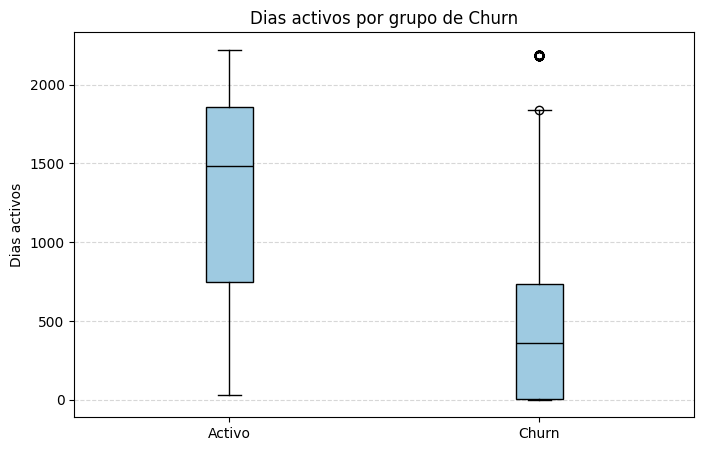

In [1470]:
# Boxplot: dias activos por grupo de Churn
data_activo = contract.loc[~contract['Churn'], 'DaysActive']
data_churn  = contract.loc[ contract['Churn'], 'DaysActive']

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([data_activo, data_churn],
           tick_labels=['Activo', 'Churn'],
           patch_artist=True,
           boxprops=dict(facecolor='#9ecae1'),
           medianprops=dict(color='black'))
ax.set_ylabel('Dias activos')
ax.set_title('Dias activos por grupo de Churn')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Lectura**

Los clientes que continúan activos llevan, en promedio, una antigüedad notablemente mayor que los que cancelaron. La mediana de los activos prácticamente duplica a la de los cancelados, lo cual ya anticipa que la antigüedad es un buen predictor del Churn.

### 4.2 Distribución de antigüedad por tipo de contrato

Se grafica la distribución de `DaysActive` para cada tipo de contrato, apilando en color oscuro la porción correspondiente a clientes que cancelaron. Cada barra agrupa intervalos de aproximadamente 92 días (un trimestre).

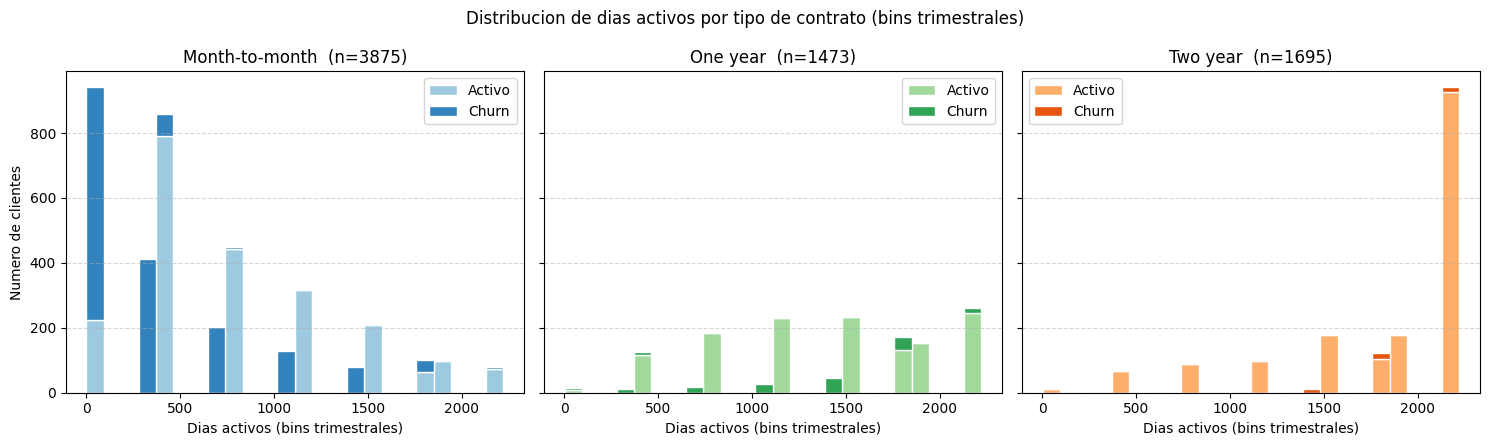

In [1471]:
# Distribucion de DaysActive: un subplot por tipo de contrato (Churn apilado)
# Bins de ~92 dias = 1 trimestre
bins = np.linspace(contract["DaysActive"].min(), contract["DaysActive"].max(), 25)

tipos = [
    ("Month-to-month", "#9ecae1", "#3182bd"),
    ("One year",       "#a1d99b", "#31a354"),
    ("Two year",       "#fdae6b", "#e6550d"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (tipo, color_activo, color_churn) in zip(axes, tipos):
    mask_tipo = contract["Type"] == tipo
    activos = contract.loc[mask_tipo & ~contract["Churn"], "DaysActive"]
    churn   = contract.loc[mask_tipo &  contract["Churn"], "DaysActive"]
    ax.hist(
        [activos, churn],
        bins=bins,
        stacked=True,
        color=[color_activo, color_churn],
        edgecolor="white",
        label=["Activo", "Churn"],
    )
    ax.set_title(f"{tipo}  (n={int(mask_tipo.sum())})")
    ax.set_xlabel("Dias activos (bins trimestrales)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend()

axes[0].set_ylabel("Numero de clientes")
fig.suptitle("Distribucion de dias activos por tipo de contrato (bins trimestrales)")
fig.tight_layout()
plt.show()

**Lectura de la gráfica**

- **Month-to-month** (n = 3 875): la distribución se concentra en los primeros meses, con un pico cercano a los 950 clientes en el primer trimestre. La porción oscura, que representa al Churn, domina los primeros 300-400 días.
- **One year** (n = 1 473): distribución prácticamente uniforme a lo largo del rango. El Churn aparece como una franja delgada y constante, sin concentrarse en ningún tramo.
- **Two year** (n = 1 695): distribución sesgada hacia la derecha, con un pico de cerca de 940 clientes en el último trimestre. La porción de Churn es testimonial.

**Conclusiones**

- El **tipo de contrato es el principal predictor de Churn**: cambia radicalmente la forma de la distribución.
- El **Churn se concentra en Month-to-month y en los primeros meses** de relación. Es ahí donde conviene focalizar los esfuerzos de retención.
- El pico final del contrato a dos años no representa Churn, sino el efecto de la fecha de corte: los clientes que han permanecido activos durante todo el periodo se acumulan en el último intervalo.
- La modalidad **One year** se ubica en una zona intermedia, estable y con bajo Churn.

**Aclaración sobre el "Churn temprano"**

En este conjunto de datos, todos los Churn ocurren en dos fechas concretas (enero de 2019 y enero de 2020). Por ello, `DaysActive` para los clientes cancelados equivale a la diferencia entre alguna de esas fechas y su `BeginDate`. Los clientes con `DaysActive` bajo y `Churn = True` son simplemente quienes ingresaron poco antes de dichas fechas, no necesariamente quienes "se aburrieron rápido". La gráfica de la sección 4.4 (tasa de Churn por año de inicio) presenta el patrón con mayor claridad.

### 4.3 Composición de la cartera por año de inicio

A continuación se observa cuántos clientes ingresaron cada año, separados por tipo de contrato y con la porción de Churn apilada en color oscuro.

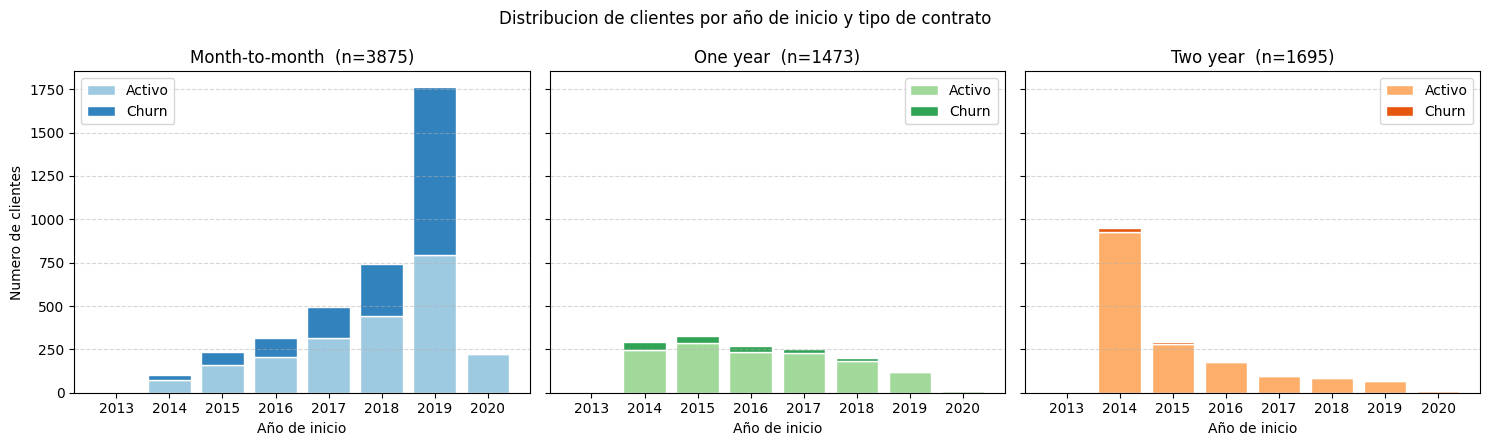

In [1472]:
# Distribucion por año de BeginDate (sin bins) - 1 subplot por tipo de contrato
# El dataset solo tiene altas en enero de cada año, asi que cada anio es 1 barra natural
datos = (contract
         .assign(_anio=contract['BeginDate'].dt.year)
         .groupby(['Type', '_anio', 'Churn'])
         .size()
         .unstack('Churn', fill_value=0)
         .rename(columns={False: 'Activo', True: 'Churn'}))

tipos = [
    ('Month-to-month', '#9ecae1', '#3182bd'),
    ('One year',       '#a1d99b', '#31a354'),
    ('Two year',       '#fdae6b', '#e6550d'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (tipo, color_activo, color_churn) in zip(axes, tipos):
    sub = datos.loc[tipo]
    ax.bar(sub.index, sub['Activo'], color=color_activo, edgecolor='white', label='Activo')
    ax.bar(sub.index, sub['Churn'], bottom=sub['Activo'], color=color_churn, edgecolor='white', label='Churn')
    n_total = int(sub.sum().sum())
    ax.set_title(f'{tipo}  (n={n_total})')
    ax.set_xlabel('Año de inicio')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend()

axes[0].set_ylabel('Numero de clientes')
fig.suptitle('Distribucion de clientes por año de inicio y tipo de contrato')
fig.tight_layout()
plt.show()

**Lectura de la gráfica**

- **Month-to-month**: la empresa creció con fuerza entre 2017 y 2019, pero los clientes que ingresaron en 2019 son los que más Churn aportan al total.
- **One year**: la captación se mantuvo estable y baja, con un Churn mínimo en todos los años.
- **Two year**: el segmento está dominado por las altas de 2014 (cerca de 926 clientes), prácticamente sin Churn — son los clientes más leales de toda la cartera.

**Conclusión**: el contrato a dos años retiene mucho más, el crecimiento agresivo en Month-to-month durante 2019 se traduce directamente en alta fuga.

### 4.4 Tasa de cancelación por año y tipo de contrato

Mientras la gráfica anterior muestra cuántos clientes hay en cada año, esta gráfica muestra **qué proporción de ellos cancelaron**. Es decir, ya no es un conteo absoluto sino una **tasa**, lo que permite comparar segmentos de tamaños muy distintos.

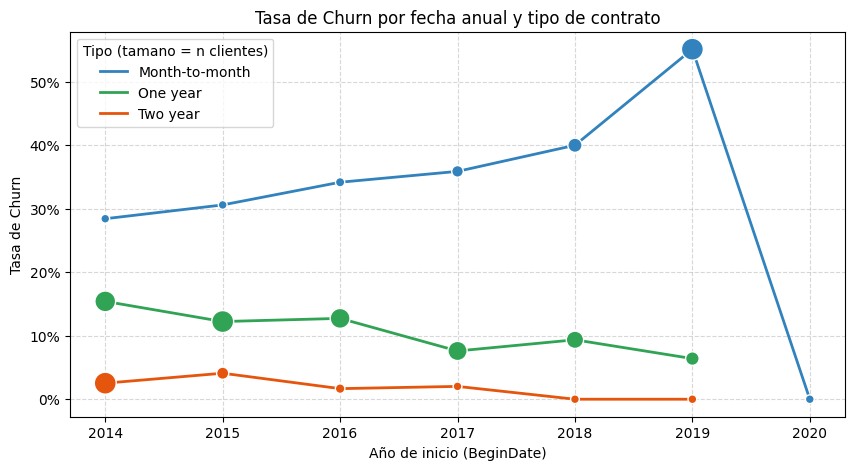

In [1473]:
# Tasa de Churn por año de inicio (año de BeginDate) y tipo de contrato
# Mas honesto que tramos de DaysActive: aqui agrupamos por cuando entro el cliente,
# no por cuanto duro (que esta acoplado al Churn por como se construye el dataset).
tasa_anual = (contract
                 .assign(_anio=contract['BeginDate'].dt.year)
                 .groupby(['Type', '_anio'], observed=True)['Churn']
                 .agg(tasa='mean', n='count')
                 .reset_index())

MIN_N = 30
tasa_anual = tasa_anual[tasa_anual['n'] >= MIN_N]

colores = {'Month-to-month': '#3182bd', 'One year': '#31a354', 'Two year': '#e6550d'}

fig, ax = plt.subplots(figsize=(10, 5))
for tipo in ['Month-to-month', 'One year', 'Two year']:
    sub = tasa_anual[tasa_anual['Type'] == tipo].sort_values('_anio')
    sizes = (sub['n'] / sub['n'].max() * 250).clip(lower=40)
    ax.plot(sub['_anio'], sub['tasa'], label=tipo, color=colores[tipo], linewidth=2, zorder=2)
    ax.scatter(sub['_anio'], sub['tasa'], s=sizes, color=colores[tipo], edgecolor='white', zorder=3)

ax.set_xlabel('Año de inicio (BeginDate)')
ax.set_ylabel('Tasa de Churn')
ax.set_title(f'Tasa de Churn por fecha anual y tipo de contrato')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.grid(linestyle='--', alpha=0.5)
ax.legend(title='Tipo (tamano = n clientes)')
plt.show()

**Lectura de la gráfica**

- En **Month-to-month**, la tasa pasa del 28 % en 2014 al 55 % en 2019: las cohortes mensuales recientes cancelan más que las antiguas.
- Se confirma una **tendencia creciente de cancelación en los contratos a corto plazo durante los últimos años**.
- Las modalidades **One year** y **Two year** se mantienen estables y bajas (entre 7 % y 15 % la primera; entre 0 % y 4 % la segunda) sin importar el año de alta.
- El **0 % observado en 2020 no es real**: corresponde a clientes que ingresaron muy poco antes de la fecha de corte y aún no tuvieron oportunidad de cancelar.

**Conclusión**: existe una relación directa entre el riesgo de cancelación y el **tipo de contrato**, y dentro del contrato Month-to-month, también una **tendencia ascendente reciente** que conviene monitorear.

*Nota técnica: los años con menos de 30 clientes se descartan (`MIN_N = 30`) para evitar porcentajes poco fiables por falta de muestra.*

## 5. Impacto económico del Churn

Esta sección traduce el problema operativo (clientes que cancelan) a un problema económico (dinero que la empresa deja de recibir). Para ello se construye una estimación del **LTV (*Life Time Value*)** por cliente y se cuantifica cuánto de ese valor permanece en la cartera y cuánto se ha perdido por Churn.

### 5.1 Cálculo del LTV por cliente

El LTV se aproxima como el cargo mensual del cliente multiplicado por su antigüedad expresada en meses (`DaysActive / 30`). La tabla descriptiva contrasta el LTV de los clientes activos contra el de los cancelados.

In [1474]:
# LTV (Life Time Value) por cliente
# Formula: cargo mensual * meses activos (DaysActive / 30)
contract['LTV'] = contract['MonthlyCharges'] * (contract['DaysActive'] / 30)

# Resumen del LTV por grupo de Churn
tabla_ltv = (contract
             .groupby('Churn')['LTV']
             .describe()
             .round(2))
tabla_ltv.index = tabla_ltv.index.map({False: 'Activo', True: 'Churn'})
display(tabla_ltv)



,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
Activo,5174.0,2887.32,2448.23,19.43,877.38,1965.72,4771.45,8791.46
Churn,1869.0,1458.96,1881.26,0.63,8.83,868.27,2226.50,8603.33


### 5.2 Distribución del LTV

El histograma muestra cómo se distribuye el LTV en cada grupo. Se observa que los clientes activos tienden a acumular un LTV más alto que los cancelados, reflejando que han pagado durante más tiempo.

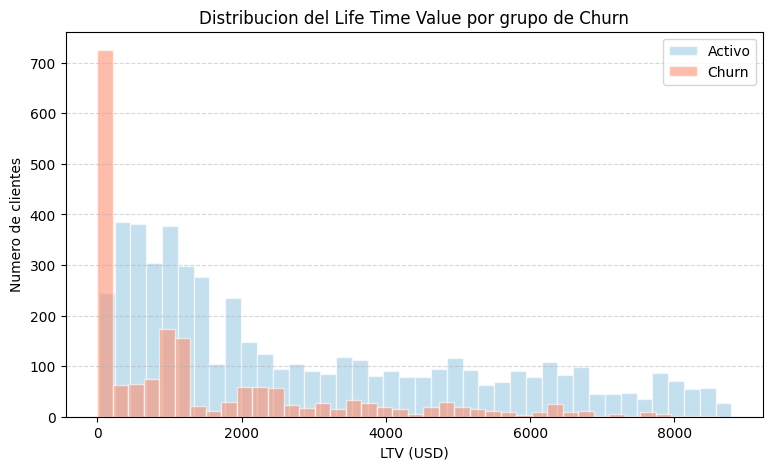

In [1475]:
# Histograma del LTV por grupo de Churn
ltv_activo = contract.loc[~contract['Churn'], 'LTV']
ltv_churn  = contract.loc[ contract['Churn'], 'LTV']

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ltv_activo, bins=40, alpha=0.6, label='Activo', color='#9ecae1', edgecolor='white')
ax.hist(ltv_churn,  bins=40, alpha=0.6, label='Churn',  color='#fc9272', edgecolor='white')
ax.set_xlabel('LTV (USD)')
ax.set_ylabel('Numero de clientes')
ax.set_title('Distribucion del Life Time Value por grupo de Churn')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 5.3 LTV retenido frente a LTV perdido

A continuación se cuantifica el impacto monetario total del Churn y se desglosa por tipo de contrato. La gráfica de la izquierda compara el LTV retenido contra el perdido en términos absolutos; la de la derecha presenta el mismo desglose dentro de cada tipo de contrato, con el porcentaje de fuga relativo etiquetado en cada barra. Las dos tablas posteriores presentan los mismos datos en forma numérica.

In [1476]:
# Agregados de LTV: total retenido, perdido y desglose por tipo de contrato
ltv_retenido = contract.loc[~contract['Churn'], 'LTV'].sum()
ltv_perdido  = contract.loc[ contract['Churn'], 'LTV'].sum()
ltv_total    = ltv_retenido + ltv_perdido

por_tipo = (contract
            .groupby(['Type', 'Churn'])['LTV'].sum()
            .unstack('Churn', fill_value=0)
            .rename(columns={False: 'Retenido', True: 'Perdido'})
            .loc[['Month-to-month', 'One year', 'Two year']])

In [1477]:
# Paleta y helper de formato monetario, consistentes con el resto de las graficas
colores_tipo = {
    'Month-to-month': ('#9ecae1', '#3182bd'),
    'One year':       ('#a1d99b', '#31a354'),
    'Two year':       ('#fdae6b', '#e6550d'),
}

def fmt_money(y, _):
    if y >= 1e6:
        return f'${y/1e6:.1f}M'
    if y >= 1e3:
        return f'${y/1e3:.0f}k'
    return f'${y:.0f}'

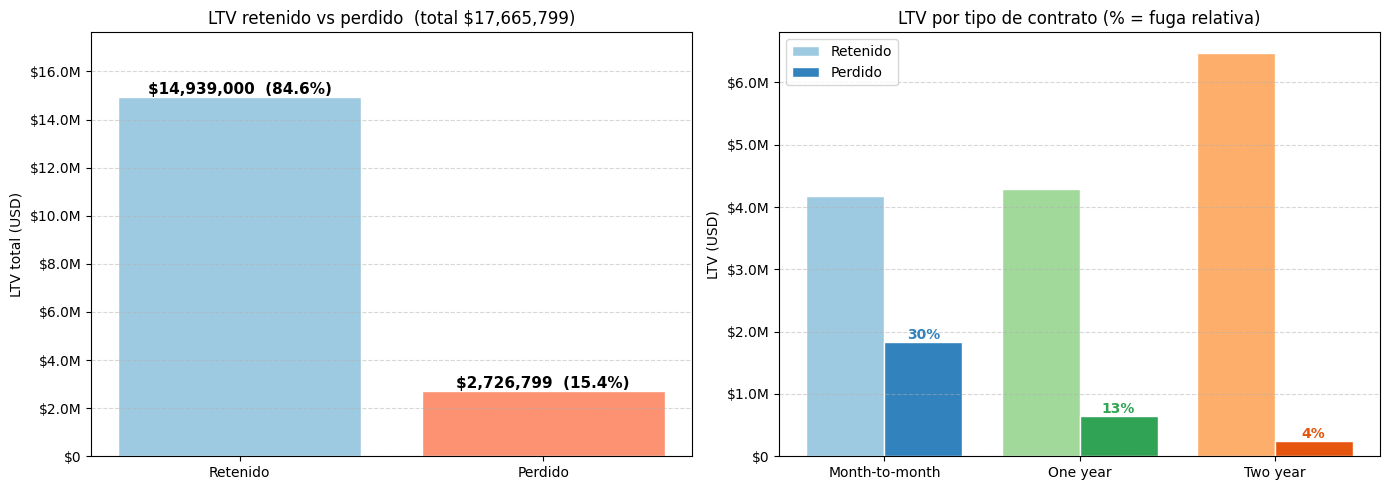

In [1478]:
# Grafica de impacto: LTV retenido vs perdido (total y por tipo de contrato)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: total ---
barras = ax1.bar(
    ['Retenido', 'Perdido'],
    [ltv_retenido, ltv_perdido],
    color=['#9ecae1', '#fc9272'],
    edgecolor='white',
)
for barra, valor in zip(barras, [ltv_retenido, ltv_perdido]):
    pct = valor / ltv_total * 100
    ax1.text(
        barra.get_x() + barra.get_width() / 2, valor,
        f'${valor:,.0f}  ({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold',
    )
ax1.set_ylabel('LTV total (USD)')
ax1.set_title(f'LTV retenido vs perdido  (total ${ltv_total:,.0f})')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(fmt_money))
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_ylim(top=max(ltv_retenido, ltv_perdido) * 1.18)

# --- Subplot 2: por tipo, par claro/oscuro por tipo ---
x = list(range(len(por_tipo)))
ancho = 0.4
for i, tipo in enumerate(por_tipo.index):
    color_claro, color_oscuro = colores_tipo[tipo]
    ret = por_tipo.loc[tipo, 'Retenido']
    perd = por_tipo.loc[tipo, 'Perdido']
    ax2.bar(i - ancho/2, ret, width=ancho, color=color_claro, edgecolor='white',
            label='Retenido' if i == 0 else None)
    ax2.bar(i + ancho/2, perd, width=ancho, color=color_oscuro, edgecolor='white',
            label='Perdido' if i == 0 else None)
    pct = perd / (ret + perd) * 100 if (ret + perd) > 0 else 0
    ax2.text(i + ancho/2, perd, f'{pct:.0f}%',
             ha='center', va='bottom', fontsize=10, color=color_oscuro, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(por_tipo.index)
ax2.set_ylabel('LTV (USD)')
ax2.set_title('LTV por tipo de contrato (% = fuga relativa)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(fmt_money))
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.legend()

fig.tight_layout()
plt.show()

In [1479]:
# Tabla 1: LTV total retenido vs perdido
tabla_total = pd.DataFrame({
    'LTV':       [ltv_retenido, ltv_perdido, ltv_total],
    '% del LTV': [ltv_retenido/ltv_total*100,
                  ltv_perdido /ltv_total*100,
                  100.0],
}, index=['Retenido', 'Perdido', 'Total'])

tabla_total.style.format({'LTV': '${:,.0f}', '% del LTV': '{:.1f}%'})

,LTV,% del LTV
Retenido,"$14,939,000",84.6%
Perdido,"$2,726,799",15.4%
Total,"$17,665,799",100.0%


In [1480]:
# Tabla 2: desglose por tipo de contrato
tabla_tipo = por_tipo.copy()
tabla_tipo['Total']           = tabla_tipo['Retenido'] + tabla_tipo['Perdido']
tabla_tipo['% Fuga']          = tabla_tipo['Perdido'] / tabla_tipo['Total'] * 100
tabla_tipo['% del LTV total'] = tabla_tipo['Total']   / ltv_total * 100

tabla_tipo.style.format({
    'Retenido':        '${:,.0f}',
    'Perdido':         '${:,.0f}',
    'Total':           '${:,.0f}',
    '% Fuga':          '{:.1f}%',
    '% del LTV total': '{:.1f}%',
})

Churn,Retenido,Perdido,Total,% Fuga,% del LTV total
Type,,,,,
Month-to-month,"$4,172,230","$1,826,371","$5,998,601",30.4%,34.0%
One year,"$4,286,370","$647,246","$4,933,616",13.1%,27.9%
Two year,"$6,480,400","$253,182","$6,733,582",3.8%,38.1%


**Lectura del impacto económico**

- La empresa ha perdido aproximadamente **$2.7 M USD** por cancelación, equivalentes al **15 % del LTV total**.
- La fuga se concentra en **Month-to-month**: $1.8 M perdidos, equivalentes al **30 % del *revenue* de su propio segmento**.
- Las modalidades **One year** y **Two year** prácticamente no presentan fuga (13 % y 4 %, respectivamente).

**Acción recomendada**: priorizar la **migración de clientes mensuales hacia contratos anuales**. Es el segmento donde se concentra la pérdida y donde la oportunidad de recuperación es mayor.

## 6. Validación estadística

Las diferencias en antigüedad observadas entre clientes activos y cancelados podrían deberse al azar. Para descartar esa posibilidad se aplica una prueba no paramétrica de Mann-Whitney U (apoyada por la prueba *t* de Welch) y se reporta el tamaño del efecto (*rank-biserial*).

In [1481]:
from scipy import stats

# Usar las columnas Churn (bool) y DaysActive ya creadas en celdas anteriores
activos = contract.loc[~contract['Churn'], 'DaysActive']
churned = contract.loc[ contract['Churn'], 'DaysActive']

# Si DaysActive sigue como timedelta, convertir a entero para los tests
if pd.api.types.is_timedelta64_dtype(activos):
    activos = activos.dt.days
    churned = churned.dt.days

print(f'Activos  n={len(activos):>5}  media={activos.mean():7.1f}  mediana={activos.median():7.1f}')
print(f'Churned  n={len(churned):>5}  media={churned.mean():7.1f}  mediana={churned.median():7.1f}')

#  3. Mann-Whitney U (no parametrico, principal)
u_stat, p_mw = stats.mannwhitneyu(activos, churned, alternative='two-sided')
print()
print(f'Mann-Whitney U = {u_stat:,.0f}   p-value = {p_mw:.3e}')

#  4. Welch t-test (apoyo)
t_stat, p_t = stats.ttest_ind(activos, churned, equal_var=False)
print(f'Welch t-test    t = {t_stat:7.3f}   p-value = {p_t:.3e}')

#  5. Tamano de efecto (rank-biserial, derivado de U)
n1, n2 = len(activos), len(churned)
r_rb = 1 - (2 * u_stat) / (n1 * n2)
print()
print(f'Rank-biserial r = {r_rb:+.3f}   (|0| sin efecto, |1| maximo)')

#  6. Resultado
alpha = 0.05
if p_mw < alpha:
    print()
    print(f'-> Rechazamos H0 (p={p_mw:.2e} < {alpha}):')
    print('   los dias activos SI difieren entre churned y no-churned.')
else:
    print()
    print(f'-> No rechazamos H0 (p={p_mw:.2e} >= {alpha}):')
    print('   sin evidencia de diferencia en dias activos.')

Activos  n= 5174  media= 1291.8  mediana= 1481.0
Churned  n= 1869  media=  516.4  mediana=  360.0

Mann-Whitney U = 8,184,410   p-value = 0.000e+00
Welch t-test    t =  45.774   p-value = 0.000e+00

Rank-biserial r = -0.693   (|0| sin efecto, |1| maximo)

-> Rechazamos H0 (p=0.00e+00 < 0.05):
   los dias activos SI difieren entre churned y no-churned.


**Lectura del resultado**

El valor `p` obtenido es prácticamente cero, muy por debajo del nivel de significancia habitual (`α = 0.05`). Se concluye que la diferencia en antigüedad entre clientes activos y cancelados **no es producto del azar**: ambos grupos provienen de poblaciones distintas. El tamaño del efecto (*rank-biserial*) confirma además que la diferencia es de magnitud relevante, no solo estadísticamente detectable.

## 7. Tabla unificada para el modelado

Para alimentar el modelo predictivo se consolidan las cuatro tablas en un único `DataFrame` mediante *left join* desde `contract`, lo que preserva a todos los clientes. Aquellos sin servicio de internet o teléfono aparecerán con valores nulos en las columnas correspondientes; esa ausencia será codificada explícitamente en la etapa de preparación de variables del modelo.

In [1482]:
df = (contract
        .merge(personal, on='CustomerID', how='left')
        .merge(internet, on='CustomerID', how='left')
        .merge(phone,    on='CustomerID', how='left'))

In [1483]:
# Verificacion de la tabla unificada
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   Churn             7043 non-null   bool          
 9   Automatic         7043 non-null   bool          
 10  DaysActive        7043 non-null   int64         
 11  LTV               7043 non-null   float64       
 12  Gender            7043 non-null   object        
 13  SeniorCitizen     7043 non-null   int64         
 14  Partner           7043 n

In [1484]:
cols_bol_cat = ['PaperlessBilling',
            'PaymentMethod',
            'Churn',
            'Automatic',
            'InternetService',
            'OnlineSecurity',
            'OnlineBackup',
            'Gender',
            'Partner',
            'SeniorCitizen',
            'DeviceProtection',
            'TechSupport',
            'StreamingTV',
            'StreamingMovies',
            'MultipleLines']


# Exploracion de distribucion de columas Boleanas y Categoricas
def value_counts_cols(df, cols):
    for col in cols:
        print(df[col].value_counts(normalize=True))
        print()

value_counts_cols(df, cols_bol_cat)

PaperlessBilling
Yes    0.592219
No     0.407781
Name: proportion, dtype: float64

PaymentMethod
Electronic check             0.335794
Mailed check                 0.228880
Bank transfer (automatic)    0.219225
Credit card (automatic)      0.216101
Name: proportion, dtype: float64

Churn
False    0.73463
True     0.26537
Name: proportion, dtype: float64

Automatic
False    0.564674
True     0.435326
Name: proportion, dtype: float64

InternetService
Fiber optic    0.561175
DSL            0.438825
Name: proportion, dtype: float64

OnlineSecurity
No     0.63404
Yes    0.36596
Name: proportion, dtype: float64

OnlineBackup
No     0.559724
Yes    0.440276
Name: proportion, dtype: float64

Gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64

Partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64

SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64

DeviceProtection
No     0.560993
Yes    0.439007
Name: proportion, dtype: floa

In [1490]:
cols = ['InternetService',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
        'MultipleLines']

df[cols] = df[cols].fillna('False').infer_objects(copy=False)

str_to_int(df, cols)

TypeError: arg must be a list, tuple, 1-d array, or Series

In [1489]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   Churn             7043 non-null   bool          
 9   Automatic         7043 non-null   bool          
 10  DaysActive        7043 non-null   int64         
 11  LTV               7043 non-null   float64       
 12  Gender            7043 non-null   object        
 13  SeniorCitizen     7043 non-null   int64         
 14  Partner           7043 n

## 8. Conclusiones

El análisis confirma que el riesgo de cancelación en Interconnect no se distribuye de manera uniforme: se concentra en un segmento específico (clientes con contrato Month-to-month) y en una etapa específica de la relación (los primeros meses). Esta doble concentración es, paradójicamente, una buena noticia para el negocio, porque indica que las acciones de retención pueden focalizarse en una porción acotada de la cartera y obtener un impacto desproporcionadamente alto.

En términos económicos, el Churn ha costado a la empresa cerca de $2.7 M USD —el 15 % del LTV total acumulado—, y casi dos terceras partes de esa pérdida provienen del segmento mensual. La validación estadística respalda la solidez de los hallazgos y la magnitud del efecto observado. El siguiente paso natural es construir un modelo predictivo que ordene a los clientes activos según su probabilidad de cancelar, para alimentar campañas de retención más quirúrgicas.

## 9. Próximos pasos — definición del modelo

Antes de iniciar el entrenamiento conviene cerrar con el área de negocio las siguientes definiciones:

- **Entregable esperado del modelo.** ¿Una lista priorizada de clientes con su probabilidad de Churn, una clasificación binaria *cancela / no cancela*, o ambas?
- **Métrica de evaluación.** Se propone **AUC-ROC** como métrica principal por las razones expuestas en el planteamiento (clases desbalanceadas, uso del modelo como rankeador). Conviene complementarla con *recall* y *precision* a un umbral operativo elegido por marketing.
- **Umbral operativo.** ¿A partir de qué probabilidad un cliente entra a la lista de contacto? La decisión depende de la capacidad operativa del equipo de retención y del costo de la promoción que se ofrecerá.
- **Frecuencia de actualización.** ¿Con qué periodicidad se reentrena el modelo y se vuelve a generar la lista (mensual, quincenal)?
- **Acción asociada.** ¿Qué se le ofrecerá al cliente identificado como riesgoso? El diseño de la promoción incide directamente en el valor que el modelo aporta al negocio.